In [7]:
%pip install -q numpy pandas matplotlib tqdm easydict scipy shapely geopandas openpyxl scikit-learn descartes pyproj seaborn

Note: you may need to restart the kernel to use updated packages.


c:\Users\user\Desktop\대학원\기초연구실\ABM code\outmigration_gym\.venv\Scripts\python.exe: No module named pip


In [8]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 노트북 파일이 있는 폴더. 다른 곳에 데이터가 있다면 경로를 바꾸세요.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR
GEOGRAPHY_DIR = PROJECT_DIR
CORE_FILE = PROJECT_DIR / 'outmigration_core.py'

required_paths = [
    CORE_FILE,
    DATA_DIR / 'ABM_city_info.xlsx',
    DATA_DIR / 'ABM_hospital_crd.xlsx',
    DATA_DIR / 'outside_polygon_mask.npy',
    GEOGRAPHY_DIR / 'Korea_shapefiles' / 'TL_SCCO_CTPRVN.shp',
]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('다음 필수 파일을 찾을 수 없습니다:\n- ' + '\n- '.join(missing))

print('입력 파일 확인 완료')

입력 파일 확인 완료


In [9]:
import importlib.util

spec = importlib.util.spec_from_file_location('outmigration_core', CORE_FILE)
core = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = core
spec.loader.exec_module(core)

print('Core module loaded:', CORE_FILE)

Core module loaded: c:\Users\user\Desktop\대학원\기초연구실\ABM code\outmigration_gym\outmigration_core.py


In [10]:
core.load_geographic_context(data_dir=DATA_DIR, geography_dir=GEOGRAPHY_DIR)
df_city_info, df_hospital_crd = core.load_simulation_inputs(data_dir=DATA_DIR)

display(df_city_info.head())
display(df_hospital_crd.head())
print(f'도시 수: {len(df_city_info):,}')
print(f'병원 좌표 행 수: {len(df_hospital_crd):,}')

c:\Users\user\Desktop\대학원\기초연구실\ABM code\outmigration_gym\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: One or several characters couldn't be converted correctly from euc-kr to UTF-8.  This warning will not be emitted anymore
  return ogr_read(
c:\Users\user\Desktop\대학원\기초연구실\ABM code\outmigration_gym\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: c:\Users\user\Desktop\대학원\기초연구실\ABM code\outmigration_gym\Korea_shapefiles\TL_SCCO_CTPRVN.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


,SIDO_NM,POPULATION_REAL,POPULATION_1,NUM_HOSPITAL,REGION
0,서울,9384739,938,14,SM
1,부산,3287292,329,4,YN
2,대구,2369962,237,5,YN
3,인천,3006045,301,3,SM
4,광주,1415774,142,2,HN


,INST_NM,ADDRESS,NUM_BED,CRD_X,CRD_Y,SIDO_NM
11,충북대병원,"충청북도 청주시 서원구 1순환로 776-0, 충북대학교병원층 (개신동)",899,241219.392714,347064.680431,충북
12,단국대병원,충청남도 천안시 동남구 망향로 201 (안서동),1059,215074.474385,370829.421252,충남
33,전북대병원,전북특별자치도 전주시 덕진구 건지로 20 (금암동),1119,212643.409434,260771.391205,전북
14,원광대병원,전북특별자치도 익산시 무왕로 895 (신동),808,196147.777505,274170.300975,전북
43,화순전남병원,전라남도 화순군 화순읍 서양로 322,684,200196.505267,173373.290319,전남


도시 수: 17
병원 좌표 행 수: 47


In [ ]:
parameter_set = core.make_default_parameter_set(df_city_info, df_hospital_crd)

# 실행 범위
parameter_set.max_dt = 100      
# parameter_set.n_p = min(28, int(df_city_info[parameter_set.target_population_column].sum()))
parameter_set.quality_model_version = 'fixed_prq'
parameter_set.n_p = 28
parameter_set.cancer_duration = 10

np.random.seed(42)
core.random.seed(4242)

In [16]:
sim = core.Simulation(parameter_set)
sim.initialize()
sim.prepare_episode()
# 2026-10-08: preserve per-hospital OHQ immediately after episode initialization.
initial_OHQ_by_hospital = sim.df_Hospital_info['OQ_objective_quality'].to_numpy().copy()

print(f'인구: {sim.num_population:,}, 병원: {sim.num_hospital:,}')
print('초기 OHQ 평균:', sim.df_Hospital_info['OQ_objective_quality'].mean())

for dt in range(parameter_set.max_dt):
    sim.advance_one_timestep(dt)
    print(f'dt={dt}: 신규 환자={sim.arr_hospital_volume[dt].sum()}, OHQ 평균={sim.achv_OHQ[dt].mean():.4f}')

인구: 5,129, 병원: 47
초기 OHQ 평균: 2.290952524518132
dt=0: 신규 환자=0, OHQ 평균=2.2910
dt=1: 신규 환자=0, OHQ 평균=2.2884
dt=2: 신규 환자=0, OHQ 평균=2.2785
dt=3: 신규 환자=0, OHQ 평균=2.2619
dt=4: 신규 환자=0, OHQ 평균=2.2414
dt=5: 신규 환자=0, OHQ 평균=2.2198
dt=6: 신규 환자=0, OHQ 평균=2.2184
dt=7: 신규 환자=0, OHQ 평균=2.2162
dt=8: 신규 환자=0, OHQ 평균=2.2134
dt=9: 신규 환자=0, OHQ 평균=2.2100
dt=10: 신규 환자=0, OHQ 평균=2.2060
dt=11: 신규 환자=0, OHQ 평균=2.2002
dt=12: 신규 환자=0, OHQ 평균=2.1935
dt=13: 신규 환자=0, OHQ 평균=2.1865
dt=14: 신규 환자=0, OHQ 평균=2.1797
dt=15: 신규 환자=0, OHQ 평균=2.1731
dt=16: 신규 환자=0, OHQ 평균=2.1671
dt=17: 신규 환자=0, OHQ 평균=2.1593
dt=18: 신규 환자=0, OHQ 평균=2.1513
dt=19: 신규 환자=0, OHQ 평균=2.1422
dt=20: 신규 환자=0, OHQ 평균=2.1338
dt=21: 신규 환자=0, OHQ 평균=2.1261
dt=22: 신규 환자=0, OHQ 평균=2.1210
dt=23: 신규 환자=0, OHQ 평균=2.1156
dt=24: 신규 환자=0, OHQ 평균=2.1099
dt=25: 신규 환자=0, OHQ 평균=2.1061
dt=26: 신규 환자=0, OHQ 평균=2.1005
dt=27: 신규 환자=0, OHQ 평균=2.0982
dt=28: 신규 환자=0, OHQ 평균=2.0942
dt=29: 신규 환자=0, OHQ 평균=2.0945
dt=30: 신규 환자=0, OHQ 평균=2.0902
dt=31: 신규 환자=0, OHQ 평균=2.0880
dt=

,hospital,region,initial_OHQ
0,건양대병원,CC,2.095012
1,단국대병원,CC,2.095012
2,충남대병원,CC,2.095012
3,충북대병원,CC,2.095012
4,강릉아산병원,GW,1.784987
5,원주세브란스병원,GW,1.784987
6,원광대병원,HN,2.129177
7,전남대병원,HN,2.129177
8,전북대병원,HN,2.129177
9,조선대병원,HN,2.129177


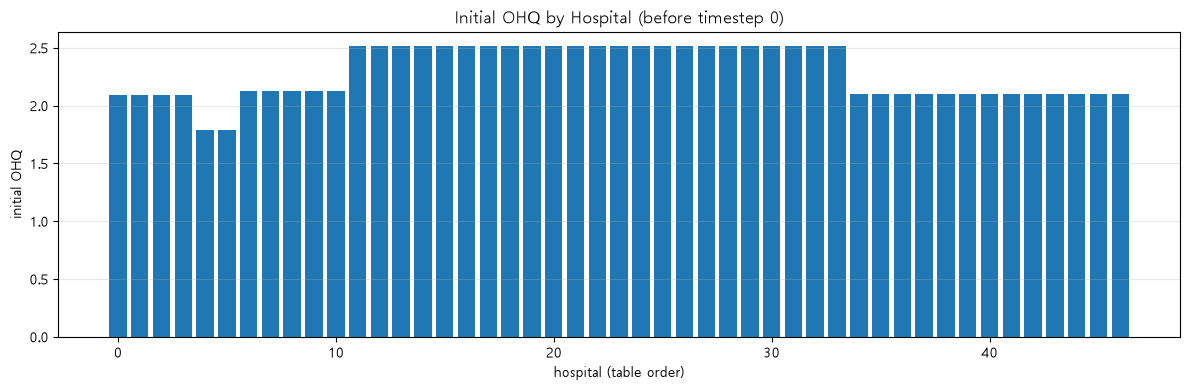

In [13]:
# 2026-10-08: inspect OHQ retained immediately after initialization, before timestep updates.
initial_ohq_table = pd.DataFrame({
    'hospital': sim.df_Hospital_info['nm_hospital'].astype(str).to_numpy(),
    'region': sim.df_Hospital_info['REGION'].to_numpy(),
    'initial_OHQ': initial_OHQ_by_hospital,
}).sort_values(['region', 'hospital']).reset_index(drop=True)
display(initial_ohq_table)

plt.figure(figsize=(12, 4))
plt.bar(np.arange(len(initial_ohq_table)), initial_ohq_table['initial_OHQ'])
plt.title('Initial OHQ by Hospital (before timestep 0)')
plt.xlabel('hospital (table order)')
plt.ylabel('initial OHQ')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

,hospital,total_new_patients,initial_OHQ,final_OHQ
0,강북삼성병원,0,2.51365,2.656568
1,서울대병원,0,2.51365,1.626170
2,이화여자대목동병원,0,2.51365,2.658174
3,서울아산병원,0,2.51365,2.644869
4,고려대병원(안암),0,2.51365,1.552250
5,한양대병원,0,2.51365,1.529474
6,가톨릭대서울성모병원,0,2.51365,1.425534
7,연세대세브란스병원,0,2.51365,1.719722
8,중앙대병원,0,2.51365,1.568408
9,경희대병원,0,2.51365,2.919951


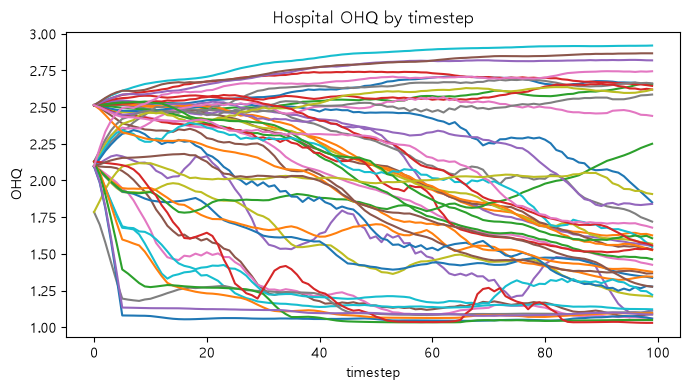

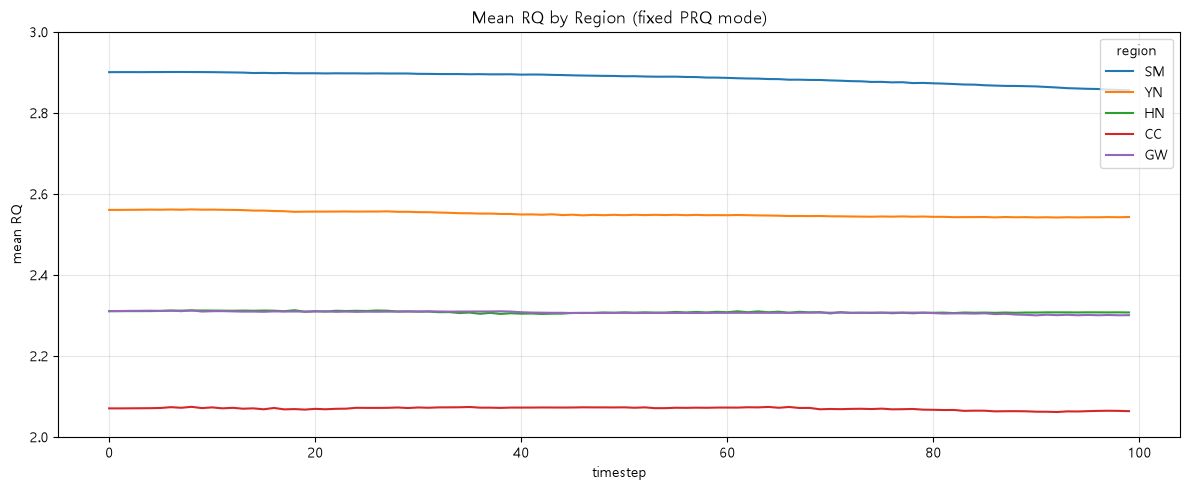

In [14]:
hospital_names = sim.df_Hospital_info['nm_hospital'].astype(str).to_numpy()
region_labels = list(parameter_set.dict_parameter_initial_PRQ.keys())
timesteps = np.arange(parameter_set.max_dt)
result = pd.DataFrame({
    'hospital': hospital_names,
    'total_new_patients': sim.arr_hospital_volume.sum(axis=0),
    'initial_OHQ': sim.achv_OHQ[0],
    'final_OHQ': sim.achv_OHQ[parameter_set.max_dt - 1],
}).sort_values('total_new_patients', ascending=False)

display(result.head(10))

plt.figure(figsize=(7, 4))

plt.plot(sim.achv_OHQ[:parameter_set.max_dt])

plt.title("Hospital OHQ by timestep")
plt.xlabel("timestep")
plt.ylabel("OHQ")

plt.tight_layout()
plt.show()

# 2026-10-06: fixed_prq 실험에서 PHQ 변화로 누적되는 지역별 평균 RQ를 확인한다.
if parameter_set.quality_model_version == 'fixed_prq':
    mean_RQ_by_region = sim.achv_population_RQ[:parameter_set.max_dt].mean(axis=1)
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx_region, region in enumerate(region_labels):
        ax.plot(timesteps, mean_RQ_by_region[:, idx_region], label=region)
    ax.set(title='Mean RQ by Region (fixed PRQ mode)', xlabel='timestep', ylabel='mean RQ', ylim=(2,3))
    ax.grid(alpha=0.3)
    ax.legend(title='region', loc='best')
    plt.tight_layout()
    plt.show()
else:
    print('RQ plot is available only when quality_model_version == fixed_prq.')

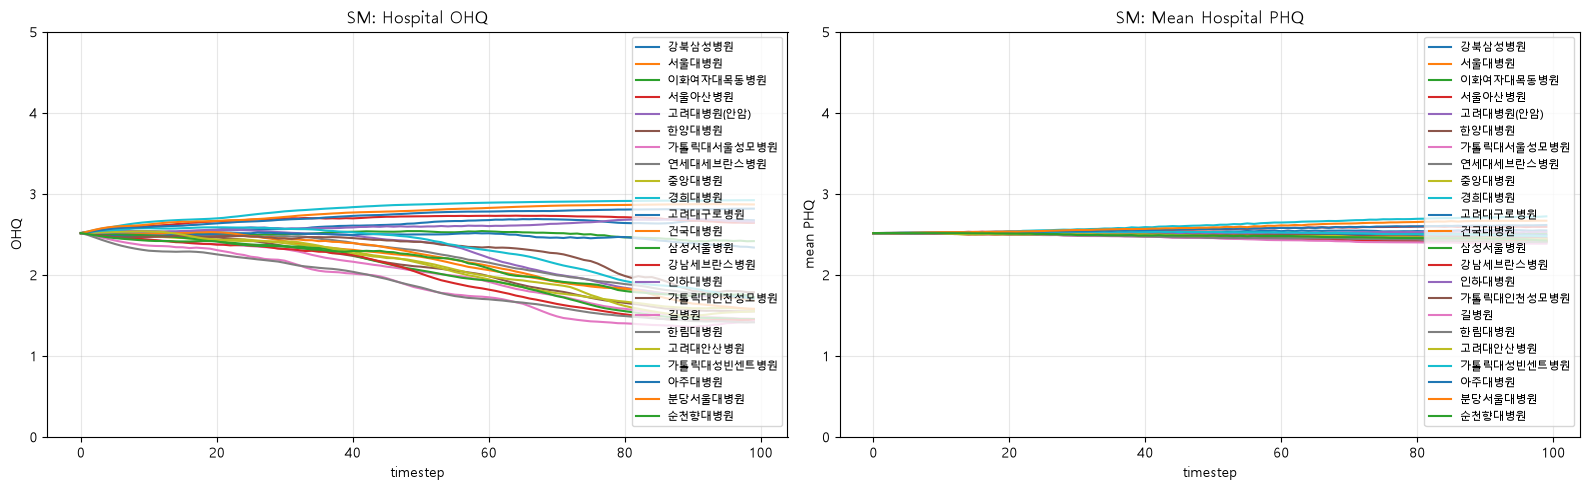

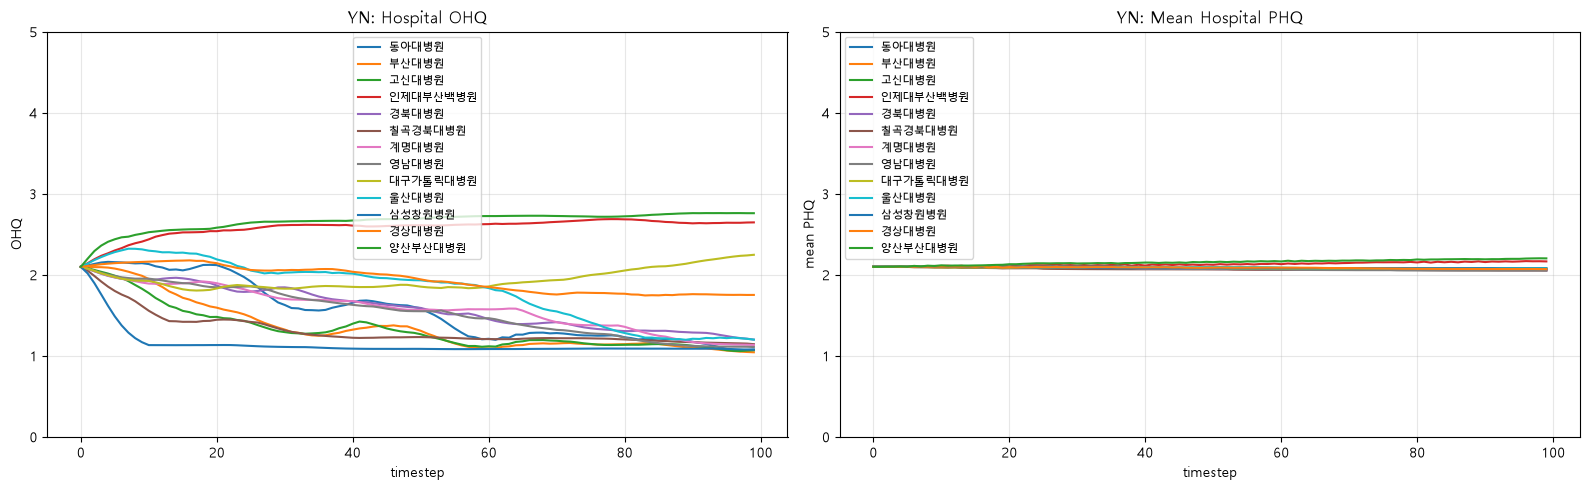

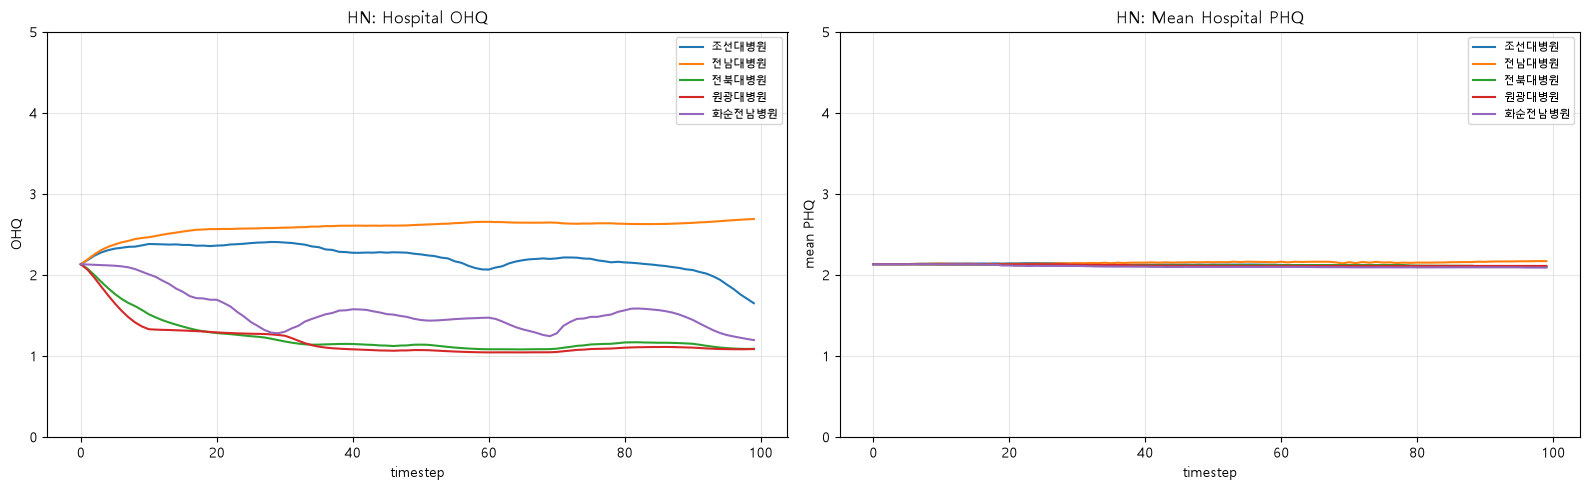

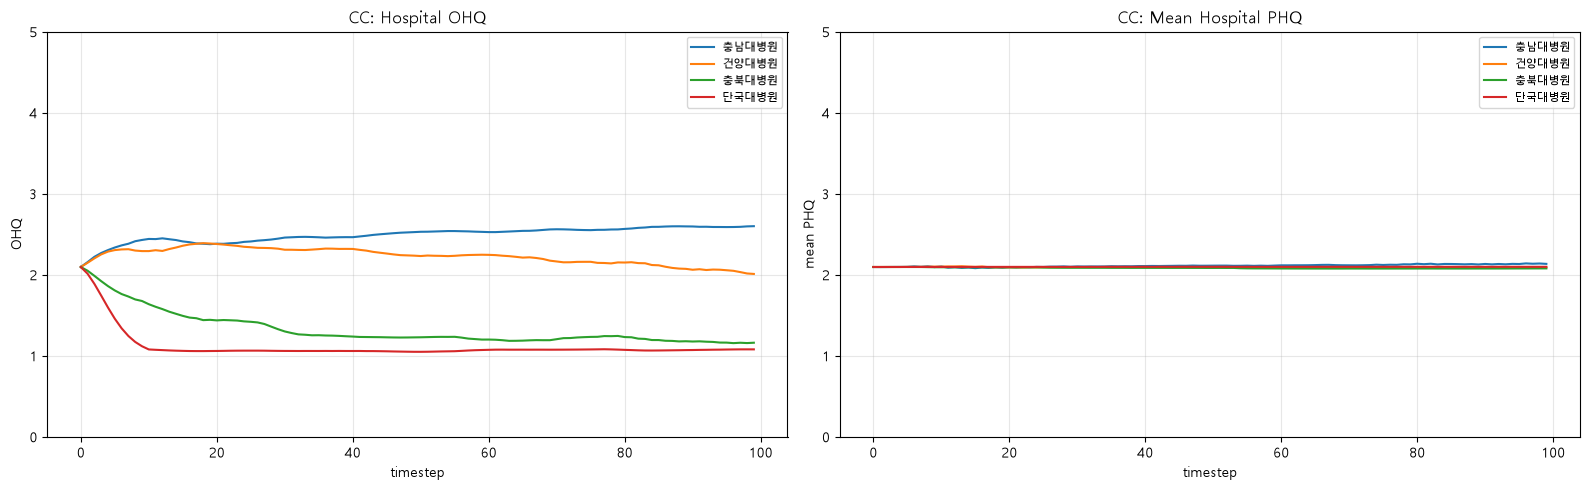

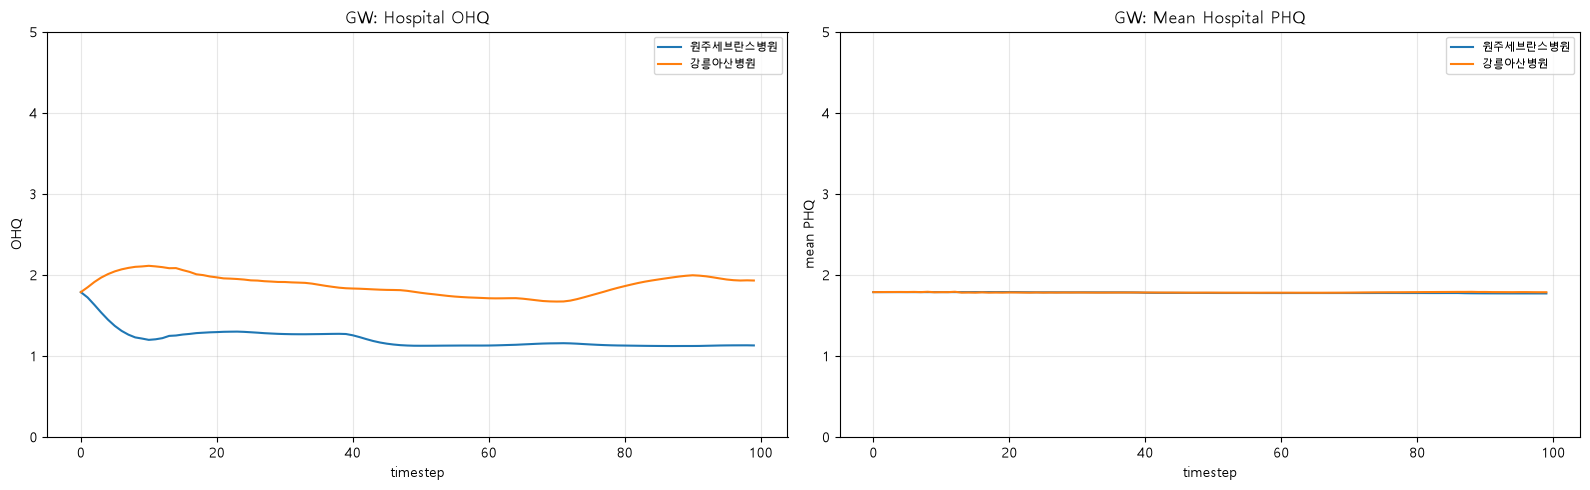

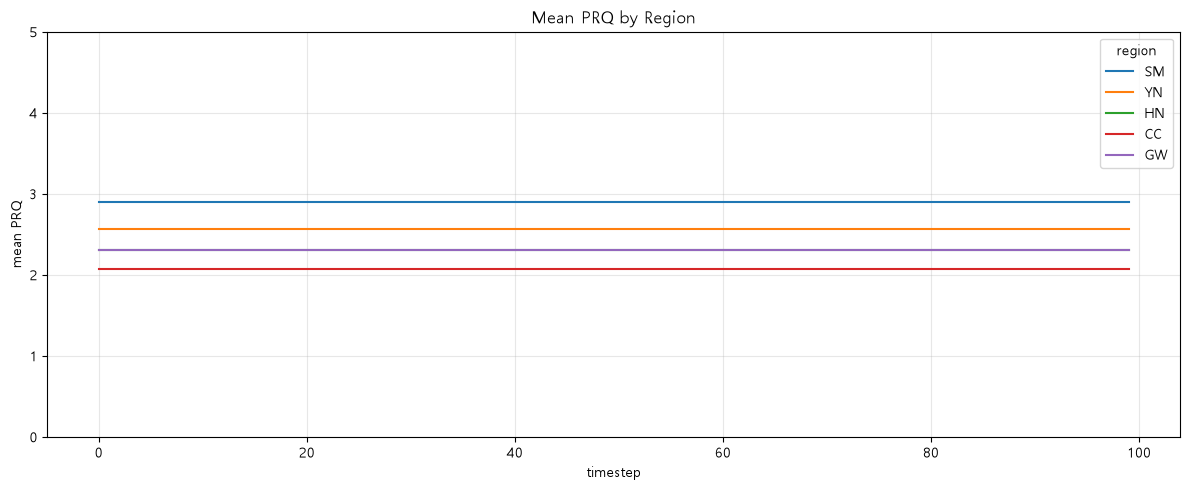

In [155]:
hospital_regions = sim.df_Hospital_info['REGION'].to_numpy()
hospital_names = sim.df_Hospital_info['nm_hospital'].astype(str).to_numpy()
timesteps = np.arange(parameter_set.max_dt)
mean_PHQ_by_hospital = sim.achv_population_PHQ[:parameter_set.max_dt].mean(axis=1)

for region in pd.unique(hospital_regions):
    idx_hospitals = np.flatnonzero(hospital_regions == region)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

    for idx_hospital in idx_hospitals:
        label = hospital_names[idx_hospital]
        axes[0].plot(timesteps, sim.achv_OHQ[:parameter_set.max_dt, idx_hospital], label=label)
        axes[1].plot(timesteps, mean_PHQ_by_hospital[:, idx_hospital], label=label)

    axes[0].set(title=f'{region}: Hospital OHQ', xlabel='timestep', ylabel='OHQ', ylim=(0, 5))
    axes[1].set(title=f'{region}: Mean Hospital PHQ', xlabel='timestep', ylabel='mean PHQ', ylim=(0, 5))
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

region_labels = list(parameter_set.dict_parameter_initial_PRQ.keys())
mean_PRQ_by_region = sim.achv_population_PRQ[:parameter_set.max_dt].mean(axis=1)
fig, ax = plt.subplots(figsize=(12, 5))
for idx_region, region in enumerate(region_labels):
    ax.plot(timesteps, mean_PRQ_by_region[:, idx_region], label=region)
ax.set(title='Mean PRQ by Region', xlabel='timestep', ylabel='mean PRQ', ylim=(0,5))
ax.grid(alpha=0.3)
ax.legend(title='region', loc='best')
plt.tight_layout()
plt.show()

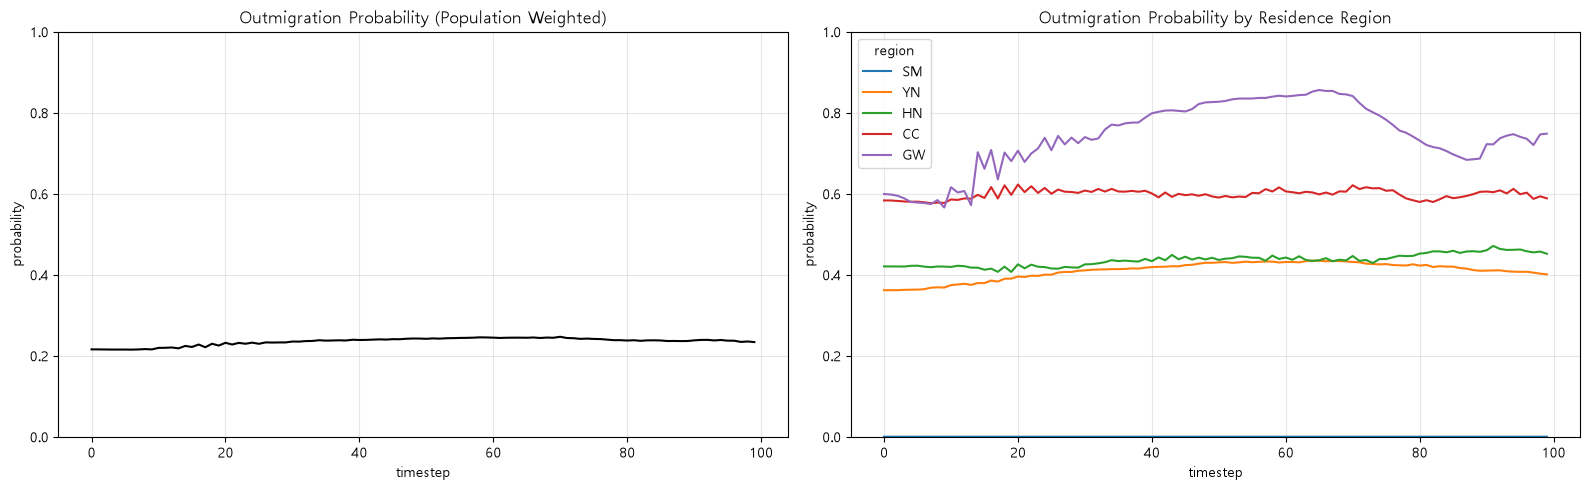

In [156]:
region_labels = list(parameter_set.dict_parameter_initial_PRQ.keys())
hospital_regions = sim.df_Hospital_info['REGION'].to_numpy()
timesteps = np.arange(parameter_set.max_dt)
prob_outmigration = np.zeros((parameter_set.max_dt, len(region_labels)))
population_by_region = np.zeros(len(region_labels), dtype=int)

for idx_region, region in enumerate(region_labels):
    idx_people = sim.df_Person_info.loc[sim.df_Person_info['REGION'] == region, 'idx_person'].to_numpy()
    idx_out_of_region_hospitals = np.flatnonzero(hospital_regions != region)
    regional_mean_choice_prob = sim.achv_population_choice_prob[:parameter_set.max_dt, idx_people, :].mean(axis=1)
    prob_outmigration[:, idx_region] = regional_mean_choice_prob[:, idx_out_of_region_hospitals].sum(axis=1)
    population_by_region[idx_region] = len(idx_people)

population_weights = population_by_region / population_by_region.sum()
prob_outmigration_population_averaged = prob_outmigration @ population_weights

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
axes[0].plot(timesteps, prob_outmigration_population_averaged, color='black')
axes[0].set(title='Outmigration Probability (Population Weighted)', xlabel='timestep', ylabel='probability', ylim=(0, 1))

for idx_region, region in enumerate(region_labels):
    axes[1].plot(timesteps, prob_outmigration[:, idx_region], label=region)
axes[1].set(title='Outmigration Probability by Residence Region', xlabel='timestep', ylabel='probability', ylim=(0, 1))

for ax in axes:
    ax.grid(alpha=0.3)
axes[1].legend(title='region', loc='best')
plt.tight_layout()
plt.show()

In [157]:
OUTPUT_DIR = PROJECT_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

result.to_excel(OUTPUT_DIR / 'hospital_summary.xlsx', index=False)
np.save(OUTPUT_DIR / 'hospital_volume.npy', sim.arr_hospital_volume)
np.save(OUTPUT_DIR / 'hospital_OHQ.npy', sim.achv_OHQ)
print('저장 위치:', OUTPUT_DIR.resolve())

저장 위치: C:\Users\user\Desktop\대학원\기초연구실\ABM code\outmigration_gym\outputs


## VOR Grid Search

Fixed-PRQ mode에서 VOR half-saturation과 Gamma time-lag sensitivity를 비교합니다.

In [ ]:
# 2026-10-07: fixed_prq VOR sensitivity grid search configuration.
RUN_GRID_SEARCH = True
MAX_DT = 100
N_SEEDS = 5
SEEDS = list(range(42, 42 + N_SEEDS))
BASE_GAMMA_ALPHA = 2.0
BASE_GAMMA_BETA = 2.0
BASE_S_HALF = 1.0 / 47.0
S_HALF_GRID = [0.25 / 47.0, 0.50 / 47.0, 1.00 / 47.0, 2.00 / 47.0, 4.00 / 47.0]
GAMMA_ALPHA_GRID = [1.0, 2.0, 3.0, 4.0]
GAMMA_BETA_GRID = [0.5, 1.0, 1.5, 2.0]

GRID_OUTPUT_DIR = PROJECT_DIR / 'outputs' / 'grid_search'
print(f'RUN_GRID_SEARCH={RUN_GRID_SEARCH}, MAX_DT={MAX_DT}, seeds={SEEDS}')

In [ ]:
# 2026-10-07: helpers and independent fixed_prq simulation runs for the VOR grid search.
import copy
import warnings
from tqdm.auto import tqdm

def _population_weighted_outmigration_probability(grid_sim, max_dt):
    regions = list(grid_sim.parameter_set.dict_parameter_initial_PRQ.keys())
    hospital_regions = grid_sim.df_Hospital_info['REGION'].to_numpy()
    probability = np.zeros((max_dt, len(regions)), dtype=float)
    population = np.zeros(len(regions), dtype=float)
    for region_idx, region in enumerate(regions):
        people = grid_sim.df_Person_info.loc[grid_sim.df_Person_info['REGION'] == region, 'idx_person'].to_numpy()
        nonlocal_hospitals = np.flatnonzero(hospital_regions != region)
        probability[:, region_idx] = (
            grid_sim.achv_population_choice_prob[:max_dt, people, :]
            .mean(axis=1)[:, nonlocal_hospitals].sum(axis=1)
        )
        population[region_idx] = len(people)
    return probability @ (population / population.sum())

def _normalized_vor_weights(grid_sim, alpha, beta):
    raw_weights = np.asarray(grid_sim.vor_weights, dtype=float)
    raw_sum = raw_weights.sum()
    if not np.isclose(raw_sum, 1.0):
        warnings.warn(
            f'Gamma weights for alpha={alpha}, beta={beta} have raw sum={raw_sum:.8f}, not 1. '
            'Changing Gamma alpha/beta can therefore change VOR input magnitude as well as timing.',
            RuntimeWarning,
        )
    if not np.isfinite(raw_sum) or raw_sum <= 0:
        return np.full_like(raw_weights, np.nan), raw_sum
    return raw_weights / raw_sum, raw_sum

def _run_vor_scenario(experiment_type, s_half, gamma_alpha, gamma_beta, seed):
    # A deep copy keeps every current notebook parameter fixed except this scenario's VOR inputs.
    grid_parameter_set = copy.deepcopy(parameter_set)
    grid_parameter_set.max_dt = MAX_DT
    grid_parameter_set.quality_model_version = 'fixed_prq'
    grid_parameter_set.eta_RQ_from_PHQ = parameter_set.eta_RQ_from_PHQ
    grid_parameter_set.S_half = s_half
    grid_parameter_set.gamma_alpha = gamma_alpha
    grid_parameter_set.gamma_beta = gamma_beta  # SciPy Gamma beta is the scale parameter.

    np.random.seed(seed)
    core.random.seed(seed + 10000)
    grid_sim = core.Simulation(grid_parameter_set)
    normalized_weights, raw_weight_sum = _normalized_vor_weights(grid_sim, gamma_alpha, gamma_beta)
    grid_sim.initialize()
    grid_sim.prepare_episode()
    for dt in range(MAX_DT):
        grid_sim.advance_one_timestep(dt)
        # 2026-10-07: core currently allocates but does not fill arr_hospital_volume.
        # Record this timestep's newly active patients only for the grid-search HHI metric.
        new_patients = np.flatnonzero(
            grid_sim.arr_active_cancer_end_dt == dt + int(grid_parameter_set.cancer_duration)
        )
        chosen_hospitals = grid_sim.df_Person_info['idx_chosen_hospital'].to_numpy()[new_patients]
        valid_choices = chosen_hospitals[chosen_hospitals >= 0]
        grid_sim.arr_hospital_volume[dt] = np.bincount(
            valid_choices, minlength=grid_sim.num_hospital
        )

    outmigration = _population_weighted_outmigration_probability(grid_sim, MAX_DT)
    ohq = np.asarray(grid_sim.achv_OHQ[:MAX_DT], dtype=float)
    if hasattr(grid_sim, 'achv_vor_OHQ'):
        vor = np.asarray(grid_sim.achv_vor_OHQ[:MAX_DT], dtype=float)
    elif (hasattr(grid_sim, 'base_OHQ') and hasattr(grid_sim, 'reinvestment_OHQ')
          and np.allclose(grid_sim.reinvestment_OHQ, 0.0)):
        vor = ohq - np.asarray(grid_sim.base_OHQ, dtype=float)[None, :]
    else:
        warnings.warn('VOR-only archive is unavailable; VOR-only metrics are recorded as NaN.', RuntimeWarning)
        vor = np.full_like(ohq, np.nan)

    total_volume = np.asarray(grid_sim.arr_hospital_volume[:MAX_DT], dtype=float).sum(axis=0)
    total_volume_sum = total_volume.sum()
    volume_hhi = np.nan if total_volume_sum == 0 else np.sum((total_volume / total_volume_sum) ** 2)
    gamma_mode = 0.0 if gamma_alpha <= 1.0 else (gamma_alpha - 1.0) * gamma_beta
    return {
        'experiment_type': experiment_type, 'S_half': s_half,
        'gamma_alpha': gamma_alpha, 'gamma_beta': gamma_beta,
        'gamma_mode': gamma_mode, 'seed': seed, 'vor_weight_raw_sum': raw_weight_sum,
        # 2026-10-07: NumPy 2.x removed np.trapz; trapezoid is the equivalent API.
        'outmigration_auc': (np.trapezoid(outmigration, dx=1.0) if hasattr(np, 'trapezoid') else np.trapz(outmigration, dx=1.0)),
        'mean_outmigration_probability': outmigration.mean(),
        'final_ohq_mean': ohq[-1].mean(), 'final_ohq_std': ohq[-1].std(),
        'final_ohq_max': ohq[-1].max(), 'overall_ohq_mean': ohq.mean(),
        'final_vor_mean': vor[-1].mean(), 'overall_vor_mean': np.nanmean(vor),
        'volume_hhi': volume_hhi,
    }, normalized_weights

SUMMARY_METRICS = ['outmigration_auc', 'mean_outmigration_probability', 'final_ohq_mean',
                   'final_ohq_std', 'final_vor_mean', 'volume_hhi']

if RUN_GRID_SEARCH:
    GRID_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    vor_K = int(parameter_set.vor_K)
    gamma_scenarios = [(alpha, beta) for alpha in GAMMA_ALPHA_GRID for beta in GAMMA_BETA_GRID
                       if (0.0 if alpha <= 1.0 else (alpha - 1.0) * beta) <= vor_K]
    s_half_scenarios = [(s_half, BASE_GAMMA_ALPHA, BASE_GAMMA_BETA) for s_half in S_HALF_GRID]
    jobs = [('s_half', *scenario, seed) for scenario in s_half_scenarios for seed in SEEDS]
    jobs += [('gamma', BASE_S_HALF, alpha, beta, seed) for alpha, beta in gamma_scenarios for seed in SEEDS]
    raw_results, gamma_weight_rows = [], []
    for experiment_type, s_half, alpha, beta, seed in tqdm(jobs, desc='VOR grid simulations'):
        row, normalized_weights = _run_vor_scenario(experiment_type, s_half, alpha, beta, seed)
        raw_results.append(row)
        if experiment_type == 'gamma' and seed == SEEDS[0]:
            gamma_weight_rows.extend({
                'gamma_alpha': alpha, 'gamma_beta': beta, 'gamma_mode': row['gamma_mode'],
                'lag': lag, 'normalized_weight': weight, 'raw_weight_sum': row['vor_weight_raw_sum'],
            } for lag, weight in enumerate(normalized_weights, start=1))

    grid_runs = pd.DataFrame(raw_results)
    s_half_runs = grid_runs.query("experiment_type == 's_half'").copy()
    gamma_runs = grid_runs.query("experiment_type == 'gamma'").copy()
    s_half_summary = s_half_runs.groupby('S_half')[SUMMARY_METRICS].agg(['mean', 'std', 'count']).reset_index()
    gamma_summary = gamma_runs.groupby(['gamma_alpha', 'gamma_beta', 'gamma_mode'])[SUMMARY_METRICS].agg(['mean', 'std', 'count']).reset_index()
    gamma_weights = pd.DataFrame(gamma_weight_rows)

    s_half_runs.to_csv(GRID_OUTPUT_DIR / 's_half_runs.csv', index=False)
    gamma_runs.to_csv(GRID_OUTPUT_DIR / 'gamma_runs.csv', index=False)
    s_half_summary.to_csv(GRID_OUTPUT_DIR / 's_half_summary.csv', index=False)
    gamma_summary.to_csv(GRID_OUTPUT_DIR / 'gamma_summary.csv', index=False)
    gamma_weights.to_csv(GRID_OUTPUT_DIR / 'gamma_weights.csv', index=False)
    print(f'Grid search saved to: {GRID_OUTPUT_DIR.resolve()}')
    print(f'Scenarios: S_half={len(s_half_scenarios)}, Gamma={len(gamma_scenarios)}; seeds={len(SEEDS)}; total runs={len(jobs)}')
else:
    print('RUN_GRID_SEARCH=False: grid search skipped; the single simulation above is unchanged.')

In [ ]:
# 2026-10-07: VOR grid-search figures (only rendered after a successful grid run).
if RUN_GRID_SEARCH:
    s_plot = s_half_runs.groupby('S_half')[['outmigration_auc', 'final_vor_mean', 'final_ohq_std', 'volume_hhi']].agg(['mean', 'std'])
    x = s_plot.index.to_numpy() / BASE_S_HALF
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, metric in zip(axes.ravel(), ['outmigration_auc', 'final_vor_mean', 'final_ohq_std', 'volume_hhi']):
        ax.errorbar(x, s_plot[(metric, 'mean')], yerr=s_plot[(metric, 'std')], marker='o', capsize=4)
        ax.set(xlabel='S_half / (1/47)', ylabel=metric, title=f'S_half sensitivity: {metric}')
        ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(GRID_OUTPUT_DIR / 's_half_sensitivity.png', dpi=160, bbox_inches='tight')
    plt.show()

    for metric in ['outmigration_auc', 'final_vor_mean', 'volume_hhi']:
        heatmap = gamma_runs.pivot_table(index='gamma_alpha', columns='gamma_beta', values=metric, aggfunc='mean')
        heatmap = heatmap.reindex(index=GAMMA_ALPHA_GRID, columns=GAMMA_BETA_GRID)
        fig, ax = plt.subplots(figsize=(7, 5))
        image = ax.imshow(heatmap, aspect='auto', origin='lower')
        ax.set(xticks=np.arange(len(GAMMA_BETA_GRID)), xticklabels=GAMMA_BETA_GRID,
               yticks=np.arange(len(GAMMA_ALPHA_GRID)), yticklabels=GAMMA_ALPHA_GRID,
               xlabel='gamma_beta (scale)', ylabel='gamma_alpha', title=f'Gamma sensitivity: {metric}')
        for row_idx in range(heatmap.shape[0]):
            for col_idx in range(heatmap.shape[1]):
                value = heatmap.iloc[row_idx, col_idx]
                ax.text(col_idx, row_idx, '' if np.isnan(value) else f'{value:.3g}', ha='center', va='center')
        fig.colorbar(image, ax=ax, label=metric)
        fig.tight_layout()
        fig.savefig(GRID_OUTPUT_DIR / f'gamma_heatmap_{metric}.png', dpi=160, bbox_inches='tight')
        plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    for (alpha, beta), weights in gamma_weights.groupby(['gamma_alpha', 'gamma_beta']):
        ax.plot(weights['lag'], weights['normalized_weight'], marker='o', label=f'a={alpha}, b={beta}')
    ax.set(xlabel='Lag (1 = most recent timestep)', ylabel='normalized Gamma weight',
           title='VOR Gamma-weight profiles (lag 1 is most recent)')
    ax.grid(alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    fig.savefig(GRID_OUTPUT_DIR / 'gamma_weight_profiles.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('RUN_GRID_SEARCH=False: no grid-search figures were created.')